# Who is adherent at 80%? Person-year t-tests

**Unit of analysis: one person-year.** Every row of `model_df_all_years.parquet` is treated
as an independent observation, so the same DUPERSID appearing in 2020 and 2022 counts as two
separate cases. A person who was non-adherent in the Midwest and adherent after moving West
contributes one row to each. Nothing here is paired, and nothing looks at year-over-year
change or trajectory class.

**Outcomes.** Every characteristic is tested against two things:

- **Adherence ratio (%)** — the continuous `meps_adherence_ratio`.
- **% adherent (≥80%)** — a 0/100 indicator for clearing the threshold, so `Mean_A` and
  `Mean_B` read as the two groups' adherent rates.

**Tests.** Welch two-sample t-tests (unequal variance). For each characteristic, every level
is tested against all other person-years combined, then against each other level pairwise.
Because each person-year is treated as independent, these p-values do not adjust for the same
person appearing in multiple years; the pooled summary at the end adds a
Benjamini–Hochberg FDR column for the multiple-comparison load.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

TABLES_DIR = Path("output/all_years/tables")

ADH_THRESHOLD = 80
RATE_COL = f"% adherent (≥{ADH_THRESHOLD}%)"
RATIO_OUTCOME = "Adherence ratio (%)"

model_df = pd.read_parquet(TABLES_DIR / "model_df_all_years.parquet")

print(
    f"Person-years: {len(model_df):,} | distinct people: {model_df['DUPERSID'].nunique():,}\n"
    f"Rows per person: "
    f"{model_df.groupby('DUPERSID').size().value_counts().sort_index().to_dict()}"
)

Person-years: 28,691 | distinct people: 18,673
Rows per person: {1: 9826, 2: 7676, 3: 1171}


In [2]:
# Person-year analysis frame: one row per observation, every characteristic labelled.
REGION_LABELS = {1: "Northeast", 2: "Midwest", 3: "South", 4: "West"}
RACETHX_LABELS = {
    1: "Hispanic",
    2: "White only",
    3: "Black only",
    4: "Asian only",
    5: "Other / multiple",
}
MARRY_LABELS = {
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
}
POV_LABELS = {
    "POV_POOR": "Poor",
    "POV_NEAR_POOR": "Near poor",
    "POV_LOW": "Low income",
    "POV_MIDDLE": "Middle income",
    "POV_HIGH": "High income",
}
INSCOV_LABELS = {
    "INSCOV_PRIVATE": "Private",
    "INSCOV_PUBLIC": "Public",
    "INSCOV_UNINSURED": "Uninsured",
}


def _one_hot_label(df, mapping):
    out = pd.Series(pd.NA, index=df.index, dtype="object")
    for col, label in mapping.items():
        out = out.mask(df[col] == 1, label)
    return out


py = model_df.copy()
py["AGE"] = pd.to_numeric(py["AGE"], errors="coerce")
# MEPS uses negative codes for missing education; keep only plausible year counts.
py["EDUCYR"] = py["EDUCYR"].where(py["EDUCYR"].between(0, 17))

py["adherent_pct"] = (py["meps_adherence_ratio"] >= ADH_THRESHOLD).astype(float) * 100
py["Adherence group"] = np.where(
    py["adherent_pct"] > 0, f"Adherent (≥{ADH_THRESHOLD}%)", f"Not adherent (<{ADH_THRESHOLD}%)"
)

py["Sex"] = np.where(py["MALE"] == 1, "Male", "Female")
py["Age group"] = pd.cut(
    py["AGE"], bins=[0, 30, 61, np.inf], labels=["Under 30", "30–60", "Above 60"], right=False
)
py["Race"] = py["RACETHX"].map(RACETHX_LABELS)
py["Marital status"] = py["MARRYXX"].map(MARRY_LABELS)
py["Education"] = pd.cut(
    py["EDUCYR"],
    bins=[-0.1, 11, 12, 15, 16, 17],
    labels=[
        "Less than high school",
        "High school (12 yrs)",
        "Some college (13–15)",
        "College (16 yrs)",
        "17+ years",
    ],
)
py["Income group"] = _one_hot_label(py, POV_LABELS)
py["Insurance"] = _one_hot_label(py, INSCOV_LABELS)
py["Cost share"] = pd.cut(
    py["PATIENT_COST_SHARE"],
    bins=[-0.001, 0.05, 0.25, 0.5, 0.75, 1.0],
    labels=["≤5% OOP", "5–25% OOP", "25–50% OOP", "50–75% OOP", ">75% OOP"],
)
py["Delayed meds (cost)"] = np.where(
    py["PMED_DELAY_COST"] == 1, "Delayed meds for cost", "No delay"
)
py["Delayed care (cost)"] = np.where(
    py["CARE_DELAY_COST"] == 1, "Delayed care for cost", "No delay"
)
py["# meds"] = pd.cut(
    py["n_drugs"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=["1 med", "2 meds", "3 meds", "4 meds", "5+ meds"],
)
py["# conditions"] = pd.cut(
    py["n_conditions"],
    bins=[0, 1, 2, 3, np.inf],
    labels=["1 condition", "2 conditions", "3 conditions", "4+ conditions"],
)
py["Dosing frequency"] = py["medication_freq_bin"]
py["Dose quartile"] = pd.qcut(
    py["medication_dose"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)
py["Region"] = py["REGIONXX"].map(REGION_LABELS)
py["Survey year"] = py["YEAR"].astype(str)

# Fixed level order for every characteristic, so tables and pairwise tests line up.
CHARACTERISTIC_LEVELS = {
    "Sex": ["Female", "Male"],
    "Age group": ["Under 30", "30–60", "Above 60"],
    "Race": ["Hispanic", "White only", "Black only", "Asian only", "Other / multiple"],
    "Marital status": ["Married", "Widowed", "Divorced", "Separated", "Never married"],
    "Education": [
        "Less than high school",
        "High school (12 yrs)",
        "Some college (13–15)",
        "College (16 yrs)",
        "17+ years",
    ],
    "Income group": ["Poor", "Near poor", "Low income", "Middle income", "High income"],
    "Insurance": ["Private", "Public", "Uninsured"],
    "Cost share": ["≤5% OOP", "5–25% OOP", "25–50% OOP", "50–75% OOP", ">75% OOP"],
    "Delayed meds (cost)": ["Delayed meds for cost", "No delay"],
    "Delayed care (cost)": ["Delayed care for cost", "No delay"],
    "# meds": ["1 med", "2 meds", "3 meds", "4 meds", "5+ meds"],
    "# conditions": ["1 condition", "2 conditions", "3 conditions", "4+ conditions"],
    "Dosing frequency": ["1x_daily", "2x_daily", "3x_daily", "4x_plus"],
    "Dose quartile": ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
    "Region": ["Northeast", "Midwest", "South", "West"],
    "Survey year": ["2020", "2021", "2022", "2023"],
}
for col, levels in CHARACTERISTIC_LEVELS.items():
    py[col] = pd.Categorical(py[col].astype("object"), categories=levels, ordered=True)

OVERALL_RATE = py["adherent_pct"].mean()
print(
    f"Threshold: ≥{ADH_THRESHOLD}%\n"
    f"Adherent person-years: {int(py['adherent_pct'].sum() / 100):,} of {len(py):,} "
    f"({OVERALL_RATE:.1f}%)\n"
    f"Mean adherence ratio: {py['meps_adherence_ratio'].mean():.1f}% | "
    f"median: {py['meps_adherence_ratio'].median():.1f}%"
)
display(py["Adherence group"].value_counts().rename("N person-years").to_frame())

Threshold: ≥80%
Adherent person-years: 7,826 of 28,691 (27.3%)
Mean adherence ratio: 60.4% | median: 61.6%


,N person-years
Adherence group,
Not adherent (<80%),20865
Adherent (≥80%),7826


In [3]:
# Welch t-test helpers. Every table produced is registered for the pooled summary.
ALL_TTESTS = []


def welch_rows(a, b, label_a, label_b, outcome):
    """Welch two-sample t-test on two value series; one summary row."""
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    row = {
        "Outcome": outcome,
        "Group A": label_a,
        "N_A": int(len(a)),
        "Mean_A": a.mean() if len(a) else np.nan,
        "Group B": label_b,
        "N_B": int(len(b)),
        "Mean_B": b.mean() if len(b) else np.nan,
        "Diff (A−B)": np.nan,
        "t": np.nan,
        "p": np.nan,
        "Significant (p<0.05)": False,
    }
    if len(a) < 2 or len(b) < 2:
        return row
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    row.update(
        {
            "Diff (A−B)": a.mean() - b.mean(),
            "t": t,
            "p": p,
            "Significant (p<0.05)": bool(p < 0.05),
        }
    )
    return row


def rate_row(a, b, label_a, label_b):
    """Welch test on the 0/100 adherent indicator: do the groups clear ≥80% at different rates?

    Needs at least 5 adherent and 5 non-adherent person-years per group, otherwise the
    statistic is driven by a degenerate cell — those rows keep the rates but no test.
    """
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if any(min(s.sum() / 100, len(s) - s.sum() / 100) < 5 for s in (a, b)):
        return {
            "Outcome": RATE_COL,
            "Group A": label_a,
            "N_A": int(len(a)),
            "Mean_A": a.mean() if len(a) else np.nan,
            "Group B": label_b,
            "N_B": int(len(b)),
            "Mean_B": b.mean() if len(b) else np.nan,
            "Diff (A−B)": np.nan,
            "t": np.nan,
            "p": np.nan,
            "Significant (p<0.05)": False,
        }
    return welch_rows(a, b, label_a, label_b, RATE_COL)


def ttest_table(rows, characteristic):
    tab = pd.DataFrame(rows)
    for c in ("Mean_A", "Mean_B", "Diff (A−B)"):
        tab[c] = tab[c].round(2)
    tab["t"] = tab["t"].round(3)
    tab["p"] = tab["p"].round(4)
    tab.insert(0, "Characteristic", characteristic)
    ALL_TTESTS.append(tab)
    return tab


def summarize_by(col):
    """Person-years, mean adherence and adherent rate for each level of a characteristic."""
    tab = (
        py[py[col].notna()]
        .groupby(col, observed=True)
        .agg(
            **{
                "N (person-years)": ("DUPERSID", "size"),
                "N people": ("DUPERSID", "nunique"),
                "Mean adherence": ("meps_adherence_ratio", "mean"),
                "Median adherence": ("meps_adherence_ratio", "median"),
                RATE_COL: ("adherent_pct", "mean"),
            }
        )
        .reset_index()
        .rename(columns={col: "Level"})
    )
    tab["Lift"] = (tab[RATE_COL] / OVERALL_RATE).round(2)
    for c in ("Mean adherence", "Median adherence", RATE_COL):
        tab[c] = tab[c].round(1)
    return tab


def analyze(col):
    """Summary table plus Welch tests: each level vs all others, then every level pair."""
    sub = py[py[col].notna()]
    levels = [lv for lv in CHARACTERISTIC_LEVELS[col] if (sub[col] == lv).any()]

    print(f"{col} — {len(sub):,} person-years, {sub['DUPERSID'].nunique():,} people")
    display(summarize_by(col))

    rows = []
    for lv in levels:
        inside = sub[sub[col] == lv]
        outside = sub[sub[col] != lv]
        rows.append(
            welch_rows(
                inside["meps_adherence_ratio"], outside["meps_adherence_ratio"],
                lv, "All other person-years", RATIO_OUTCOME,
            )
        )
        rows.append(
            rate_row(inside["adherent_pct"], outside["adherent_pct"], lv, "All other person-years")
        )
    for i, lv1 in enumerate(levels):
        for lv2 in levels[i + 1 :]:
            g1 = sub[sub[col] == lv1]
            g2 = sub[sub[col] == lv2]
            rows.append(
                welch_rows(
                    g1["meps_adherence_ratio"], g2["meps_adherence_ratio"],
                    lv1, lv2, RATIO_OUTCOME,
                )
            )
            rows.append(rate_row(g1["adherent_pct"], g2["adherent_pct"], lv1, lv2))

    tab = ttest_table(rows, col)
    print(f"Welch t-tests — each level vs all others, then pairwise")
    display(tab)
    return tab


print("Helpers ready.")

Helpers ready.


## 1. Adherent vs non-adherent person-years

The simplest cut: split every person-year into adherent (≥80%) and not, then test whether the
two groups differ on each continuous covariate. `Mean_A` is the adherent group's average.

In [4]:
# Do adherent person-years differ from non-adherent ones on each continuous covariate?
CONTINUOUS_COVARIATES = {
    "Age (years)": "AGE",
    "Family income ($)": "FAMINC",
    "Patient cost share (0–1)": "PATIENT_COST_SHARE",
    "Number of medications": "n_drugs",
    "Number of conditions": "n_conditions",
    "Dosing frequency (per day)": "medication_freq",
    "Medication dose": "medication_dose",
    "Years of education": "EDUCYR",
}

adherent = py[py["adherent_pct"] > 0]
not_adherent = py[py["adherent_pct"] == 0]

print(
    f"Adherent (≥{ADH_THRESHOLD}%): {len(adherent):,} person-years | "
    f"Not adherent: {len(not_adherent):,} person-years"
)

covariate_ttests = ttest_table(
    [
        welch_rows(
            adherent[col],
            not_adherent[col],
            f"Adherent (≥{ADH_THRESHOLD}%)",
            f"Not adherent (<{ADH_THRESHOLD}%)",
            label,
        )
        for label, col in CONTINUOUS_COVARIATES.items()
    ],
    "Adherent vs not adherent",
)
display(covariate_ttests)

print("Medians as well, since dose and income are heavily skewed")
display(
    py.groupby("Adherence group")[list(CONTINUOUS_COVARIATES.values())]
    .median()
    .round(2)
    .T.reset_index()
    .rename(columns={"index": "Covariate"})
)

Adherent (≥80%): 7,826 person-years | Not adherent: 20,865 person-years


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Adherent vs not adherent,Age (years),Adherent (≥80%),7826,60.52,Not adherent (<80%),20859,58.43,2.09,9.169,0.0000,True
1,Adherent vs not adherent,Family income ($),Adherent (≥80%),7826,78384.10,Not adherent (<80%),20865,76957.88,1426.22,1.406,0.1596,False
2,Adherent vs not adherent,Patient cost share (0–1),Adherent (≥80%),7826,0.40,Not adherent (<80%),20865,0.37,0.02,4.328,0.0000,True
3,Adherent vs not adherent,Number of medications,Adherent (≥80%),7826,2.51,Not adherent (<80%),20865,2.61,-0.10,-3.928,0.0001,True
4,Adherent vs not adherent,Number of conditions,Adherent (≥80%),7826,1.96,Not adherent (<80%),20865,1.99,-0.04,-2.408,0.0160,True
5,Adherent vs not adherent,Dosing frequency (per day),Adherent (≥80%),7823,1.42,Not adherent (<80%),20856,1.43,-0.01,-1.248,0.2121,False
6,Adherent vs not adherent,Medication dose,Adherent (≥80%),7717,421.10,Not adherent (<80%),20508,408.05,13.05,0.436,0.6630,False
7,Adherent vs not adherent,Years of education,Adherent (≥80%),7777,13.18,Not adherent (<80%),20683,12.94,0.24,5.334,0.0000,True


Medians as well, since dose and income are heavily skewed


Adherence group,Covariate,Adherent (≥80%),Not adherent (<80%)
0,AGE,64.0,62.0
1,FAMINC,55054.0,54200.0
2,PATIENT_COST_SHARE,0.23,0.19
3,n_drugs,2.0,2.0
4,n_conditions,2.0,2.0
5,medication_freq,1.3,1.33
6,medication_dose,74.0,75.9
7,EDUCYR,13.0,13.0


## 2. Demographics

Sex, age group, race, marital status, and education. Each level is tested against all other
person-years, then against each other level.

In [5]:
for i, col in enumerate(["Sex", "Age group", "Race", "Marital status", "Education"]):
    if i:
        print()
    analyze(col)

Sex — 28,691 person-years, 18,673 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,Female,16088,10436,59.8,60.3,26.5,0.97
1,Male,12603,8239,61.2,62.2,28.3,1.04


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Sex,Adherence ratio (%),Female,16088,59.81,All other person-years,12603,61.16,-1.34,-4.194,0.0000,True
1,Sex,% adherent (≥80%),Female,16088,26.45,All other person-years,12603,28.33,-1.87,-3.525,0.0004,True
2,Sex,Adherence ratio (%),Male,12603,61.16,All other person-years,16088,59.81,1.34,4.194,0.0000,True
3,Sex,% adherent (≥80%),Male,12603,28.33,All other person-years,16088,26.45,1.87,3.525,0.0004,True
4,Sex,Adherence ratio (%),Female,16088,59.81,Male,12603,61.16,-1.34,-4.194,0.0000,True
5,Sex,% adherent (≥80%),Female,16088,26.45,Male,12603,28.33,-1.87,-3.525,0.0004,True



Age group — 28,685 person-years, 18,670 people


...

,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Marital status,Adherence ratio (%),Married,13665,61.31,All other person-years,14170,60.38,0.92,2.879,0.0040,True
1,Marital status,% adherent (≥80%),Married,13665,28.22,All other person-years,14170,26.97,1.25,2.337,0.0194,True
2,Marital status,Adherence ratio (%),Widowed,3759,62.60,All other person-years,24076,60.56,2.04,4.547,0.0000,True
3,Marital status,% adherent (≥80%),Widowed,3759,28.04,All other person-years,24076,27.51,0.53,0.674,0.5003,False
4,Marital status,Adherence ratio (%),Divorced,5092,61.62,All other person-years,22743,60.66,0.96,2.368,0.0179,True
5,Marital status,% adherent (≥80%),Divorced,5092,27.85,All other person-years,22743,27.52,0.33,0.471,0.6377,False
6,Marital status,Adherence ratio (%),Separated,738,60.41,All other person-years,27097,60.85,-0.43,-0.422,0.6730,False
7,Marital status,% adherent (≥80%),Separated,738,28.05,All other person-years,27097,27.57,0.48,0.287,0.7742,False
8,Marital status,Adherence ratio (%),Never married,4581,57.17,All other person-years,23254,61.56,-4.38,-9.742,0.0000,True
9,Marital status,% adherent (≥80%),Never married,4581,24.93,All other person-years,23254,28.10,-3.17,-4.509,0.0000,True



Education — 28,460 person-years, 18,489 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,Less than high school,5023,3282,57.2,57.5,24.6,0.90
1,High school (12 yrs),8140,5265,61.4,62.2,27.5,1.01
2,Some college (13–15),6403,4127,60.7,61.6,27.0,0.99
3,College (16 yrs),5024,3272,61.5,62.3,29.0,1.06
4,17+ years,3870,2543,61.3,61.6,28.7,1.05


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Education,Adherence ratio (%),Less than high school,5023,57.20,All other person-years,23437,61.18,-3.98,-9.273,0.0000,True
1,Education,% adherent (≥80%),Less than high school,5023,24.61,All other person-years,23437,27.91,-3.30,-4.894,0.0000,True
2,Education,Adherence ratio (%),High school (12 yrs),8140,61.35,All other person-years,20320,60.13,1.22,3.481,0.0005,True
3,Education,% adherent (≥80%),High school (12 yrs),8140,27.52,All other person-years,20320,27.25,0.27,0.460,0.6453,False
4,Education,Adherence ratio (%),Some college (13–15),6403,60.70,All other person-years,22057,60.42,0.28,0.735,0.4623,False
5,Education,% adherent (≥80%),Some college (13–15),6403,27.05,All other person-years,22057,27.41,-0.36,-0.565,0.5723,False
6,Education,Adherence ratio (%),College (16 yrs),5024,61.46,All other person-years,23436,60.27,1.19,2.839,0.0045,True
7,Education,% adherent (≥80%),College (16 yrs),5024,29.04,All other person-years,23436,26.96,2.08,2.962,0.0031,True
8,Education,Adherence ratio (%),17+ years,3870,61.28,All other person-years,24590,60.36,0.93,1.992,0.0464,True
9,Education,% adherent (≥80%),17+ years,3870,28.68,All other person-years,24590,27.11,1.57,2.011,0.0444,True


## 3. Money: income, insurance, cost sharing, and cost-driven delays

In [6]:
for i, col in enumerate(
    ["Income group", "Insurance", "Cost share", "Delayed meds (cost)", "Delayed care (cost)"]
):
    if i:
        print()
    analyze(col)

Income group — 28,691 person-years, 18,673 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,Poor,4603,3511,58.5,59.1,24.5,0.90
1,Near poor,1518,1369,60.4,60.7,27.7,1.01
2,Low income,4000,3427,60.8,61.6,27.9,1.02
3,Middle income,7785,6294,60.7,62.0,27.5,1.01
4,High income,10785,7979,60.9,61.6,28.0,1.03


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Income group,Adherence ratio (%),Poor,4603,58.55,All other person-years,24088,60.76,-2.21,-5.132,0.0000,True
1,Income group,% adherent (≥80%),Poor,4603,24.51,All other person-years,24088,27.81,-3.30,-4.738,0.0000,True
2,Income group,Adherence ratio (%),Near poor,1518,60.35,All other person-years,27173,60.41,-0.06,-0.078,0.9378,False
3,Income group,% adherent (≥80%),Near poor,1518,27.67,All other person-years,27173,27.25,0.41,0.350,0.7264,False
4,Income group,Adherence ratio (%),Low income,4000,60.76,All other person-years,24691,60.35,0.41,0.911,0.3622,False
5,Income group,% adherent (≥80%),Low income,4000,27.90,All other person-years,24691,27.18,0.72,0.948,0.3431,False
6,Income group,Adherence ratio (%),Middle income,7785,60.70,All other person-years,20906,60.29,0.40,1.128,0.2595,False
7,Income group,% adherent (≥80%),Middle income,7785,27.54,All other person-years,20906,27.18,0.36,0.610,0.5420,False
8,Income group,Adherence ratio (%),High income,10785,60.86,All other person-years,17906,60.13,0.73,2.215,0.0268,True
9,Income group,% adherent (≥80%),High income,10785,27.98,All other person-years,17906,26.85,1.13,2.079,0.0377,True



Insurance — 28,691 person-years, 18,673 people


...

,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Delayed meds (cost),Adherence ratio (%),Delayed meds for cost,1395,57.14,All other person-years,27296,60.57,-3.43,-4.790,0.0,True
1,Delayed meds (cost),% adherent (≥80%),Delayed meds for cost,1395,21.72,All other person-years,27296,27.56,-5.84,-5.137,0.0,True
2,Delayed meds (cost),Adherence ratio (%),No delay,27296,60.57,All other person-years,1395,57.14,3.43,4.790,0.0,True
3,Delayed meds (cost),% adherent (≥80%),No delay,27296,27.56,All other person-years,1395,21.72,5.84,5.137,0.0,True
4,Delayed meds (cost),Adherence ratio (%),Delayed meds for cost,1395,57.14,No delay,27296,60.57,-3.43,-4.790,0.0,True
5,Delayed meds (cost),% adherent (≥80%),Delayed meds for cost,1395,21.72,No delay,27296,27.56,-5.84,-5.137,0.0,True



Delayed care (cost) — 28,691 person-years, 18,673 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,Delayed care for cost,2043,1761,57.9,57.5,24.1,0.88
1,No delay,26648,17722,60.6,61.6,27.5,1.01


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Delayed care (cost),Adherence ratio (%),Delayed care for cost,2043,57.92,All other person-years,26648,60.59,-2.67,-4.299,0.0000,True
1,Delayed care (cost),% adherent (≥80%),Delayed care for cost,2043,24.13,All other person-years,26648,27.52,-3.39,-3.436,0.0006,True
2,Delayed care (cost),Adherence ratio (%),No delay,26648,60.59,All other person-years,2043,57.92,2.67,4.299,0.0000,True
3,Delayed care (cost),% adherent (≥80%),No delay,26648,27.52,All other person-years,2043,24.13,3.39,3.436,0.0006,True
4,Delayed care (cost),Adherence ratio (%),Delayed care for cost,2043,57.92,No delay,26648,60.59,-2.67,-4.299,0.0000,True
5,Delayed care (cost),% adherent (≥80%),Delayed care for cost,2043,24.13,No delay,26648,27.52,-3.39,-3.436,0.0006,True


## 4. Regimen: medication count, conditions, dosing frequency, and dose

In [7]:
for i, col in enumerate(["# meds", "# conditions", "Dosing frequency", "Dose quartile"]):
    if i:
        print()
    analyze(col)

# meds — 28,691 person-years, 18,673 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,1 med,11185,8775,56.1,49.3,28.8,1.05
1,2 meds,6412,5213,60.9,61.6,26.0,0.95
2,3 meds,4271,3497,62.9,64.8,26.5,0.97
3,4 meds,2679,2265,64.6,65.8,27.0,0.99
4,5+ meds,4144,2892,65.9,67.3,26.3,0.97


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,# meds,Adherence ratio (%),1 med,11185,56.13,All other person-years,17506,63.13,-7.00,-20.210,0.0000,True
1,# meds,% adherent (≥80%),1 med,11185,28.75,All other person-years,17506,26.33,2.42,4.461,0.0000,True
2,# meds,Adherence ratio (%),2 meds,6412,60.86,All other person-years,22279,60.27,0.59,1.595,0.1108,False
3,# meds,% adherent (≥80%),2 meds,6412,25.97,All other person-years,22279,27.65,-1.69,-2.702,0.0069,True
4,# meds,Adherence ratio (%),3 meds,4271,62.92,All other person-years,24420,59.96,2.96,7.455,0.0000,True
5,# meds,% adherent (≥80%),3 meds,4271,26.46,All other person-years,24420,27.42,-0.96,-1.313,0.1891,False
6,# meds,Adherence ratio (%),4 meds,2679,64.62,All other person-years,26012,59.97,4.65,10.430,0.0000,True
7,# meds,% adherent (≥80%),4 meds,2679,27.03,All other person-years,26012,27.30,-0.28,-0.308,0.7580,False
8,# meds,Adherence ratio (%),5+ meds,4144,65.90,All other person-years,24547,59.48,6.43,18.507,0.0000,True
9,# meds,% adherent (≥80%),5+ meds,4144,26.33,All other person-years,24547,27.44,-1.11,-1.498,0.1343,False


# conditions — 28,691 person-years, 18,673 people


...

,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Dosing frequency,Adherence ratio (%),1x_daily,13263,60.25,All other person-years,15416,60.55,-0.30,-0.937,0.3487,False
1,Dosing frequency,% adherent (≥80%),1x_daily,13263,27.90,All other person-years,15416,26.74,1.17,2.209,0.0272,True
2,Dosing frequency,Adherence ratio (%),2x_daily,13143,61.15,All other person-years,15536,59.78,1.37,4.321,0.0000,True
3,Dosing frequency,% adherent (≥80%),2x_daily,13143,26.62,All other person-years,15536,27.83,-1.21,-2.294,0.0218,True
4,Dosing frequency,Adherence ratio (%),3x_daily,1837,57.77,All other person-years,26842,60.59,-2.82,-4.073,0.0000,True
5,Dosing frequency,% adherent (≥80%),3x_daily,1837,27.87,All other person-years,26842,27.24,0.63,0.587,0.5574,False
6,Dosing frequency,Adherence ratio (%),4x_plus,436,54.04,All other person-years,28243,60.51,-6.47,-4.339,0.0000,True
7,Dosing frequency,% adherent (≥80%),4x_plus,436,25.46,All other person-years,28243,27.31,-1.85,-0.877,0.3808,False
8,Dosing frequency,Adherence ratio (%),1x_daily,13263,60.25,2x_daily,13143,61.15,-0.90,-2.749,0.0060,True
9,Dosing frequency,% adherent (≥80%),1x_daily,13263,27.90,2x_daily,13143,26.62,1.28,2.340,0.0193,True



Dose quartile — 28,225 person-years, 18,395 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,Q1 (lowest),7058,5516,60.2,61.2,28.6,1.05
1,Q2,7061,5689,60.5,61.6,27.0,0.99
2,Q3,7050,5621,61.1,61.9,26.7,0.98
3,Q4 (highest),7056,5419,60.4,61.6,27.0,0.99


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Dose quartile,Adherence ratio (%),Q1 (lowest),7058,60.22,All other person-years,21167,60.66,-0.44,-1.140,0.2543,False
1,Dose quartile,% adherent (≥80%),Q1 (lowest),7058,28.63,All other person-years,21167,26.91,1.72,2.788,0.0053,True
2,Dose quartile,Adherence ratio (%),Q2,7061,60.54,All other person-years,21164,60.56,-0.02,-0.050,0.9597,False
3,Dose quartile,% adherent (≥80%),Q2,7061,27.02,All other person-years,21164,27.45,-0.43,-0.697,0.4859,False
4,Dose quartile,Adherence ratio (%),Q3,7050,61.07,All other person-years,21175,60.38,0.69,1.931,0.0535,False
5,Dose quartile,% adherent (≥80%),Q3,7050,26.71,All other person-years,21175,27.55,-0.84,-1.381,0.1674,False
6,Dose quartile,Adherence ratio (%),Q4 (highest),7056,60.37,All other person-years,21169,60.61,-0.24,-0.649,0.5164,False
7,Dose quartile,% adherent (≥80%),Q4 (highest),7056,27.00,All other person-years,21169,27.46,-0.46,-0.748,0.4546,False
8,Dose quartile,Adherence ratio (%),Q1 (lowest),7058,60.22,Q2,7061,60.54,-0.31,-0.676,0.4992,False
9,Dose quartile,% adherent (≥80%),Q1 (lowest),7058,28.63,Q2,7061,27.02,1.61,2.138,0.0325,True


## 5. Geography and survey year

In [8]:
for i, col in enumerate(["Region", "Survey year"]):
    if i:
        print()
    analyze(col)

Region — 28,691 person-years, 18,673 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,Northeast,4001,2576,61.3,62.3,29.0,1.06
1,Midwest,6588,4299,63.2,65.8,30.4,1.11
2,South,11012,7224,58.8,58.6,25.1,0.92
3,West,7090,4634,59.8,60.3,26.8,0.98


Welch t-tests — each level vs all others, then pairwise


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Region,Adherence ratio (%),Northeast,4001,61.34,All other person-years,24690,60.25,1.08,2.333,0.0197,True
1,Region,% adherent (≥80%),Northeast,4001,28.99,All other person-years,24690,27.00,1.99,2.586,0.0097,True
2,Region,Adherence ratio (%),Midwest,6588,63.22,All other person-years,22103,59.57,3.65,9.812,0.0000,True
3,Region,% adherent (≥80%),Midwest,6588,30.40,All other person-years,22103,26.34,4.06,6.346,0.0000,True
4,Region,Adherence ratio (%),South,11012,58.76,All other person-years,17679,61.43,-2.66,-8.138,0.0000,True
5,Region,% adherent (≥80%),South,11012,25.09,All other person-years,17679,28.64,-3.55,-6.630,0.0000,True
6,Region,Adherence ratio (%),West,7090,59.81,All other person-years,21601,60.60,-0.79,-2.132,0.0330,True
7,Region,% adherent (≥80%),West,7090,26.80,All other person-years,21601,27.43,-0.64,-1.047,0.2953,False
8,Region,Adherence ratio (%),Northeast,4001,61.34,Midwest,6588,63.22,-1.88,-3.484,0.0005,True
9,Region,% adherent (≥80%),Northeast,4001,28.99,Midwest,6588,30.40,-1.41,-1.543,0.1228,False



Survey year — 28,691 person-years, 18,673 people


,Level,N (person-years),N people,Mean adherence,Median adherence,% adherent (≥80%),Lift
0,2020,7718,7718,61.6,63.0,29.5,1.08
1,2021,8377,8377,60.3,61.6,26.6,0.97
2,2022,6770,6770,60.2,60.7,27.2,1.00
3,2023,5826,5826,59.2,59.5,25.4,0.93


Welch t-tests — each level vs all others, then pairwise

,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05)
0,Survey year,Adherence ratio (%),2020,7718,61.61,All other person-years,20973,59.96,1.65,4.569,0.0000,True
1,Survey year,% adherent (≥80%),2020,7718,29.49,All other person-years,20973,26.46,3.03,5.029,0.0000,True
2,Survey year,Adherence ratio (%),2021,8377,60.32,All other person-years,20314,60.44,-0.12,-0.345,0.7300,False
3,Survey year,% adherent (≥80%),2021,8377,26.58,All other person-years,20314,27.56,-0.98,-1.698,0.0895,False
4,Survey year,Adherence ratio (%),2022,6770,60.17,All other person-years,21921,60.48,-0.31,-0.831,0.4058,False
5,Survey year,% adherent (≥80%),2022,6770,27.24,All other person-years,21921,27.29,-0.05,-0.083,0.9342,False
6,Survey year,Adherence ratio (%),2023,5826,59.21,All other person-years,22865,60.71,-1.50,-3.819,0.0001,True
7,Survey year,% adherent (≥80%),2023,5826,25.39,All other person-years,22865,27.76,-2.37,-3.692,0.0002,True
8,Survey year,Adherence ratio (%),2020,7718,61.61,2021,8377,60.32,1.29,3.033,0.0024,True
9,Survey year,% adherent (≥80%),2020,7718,29.49,2021,8377,26.58,2.90,4.098,0.0000,True


## 6. Pooled summary

Every Welch test above in one table, with a Benjamini–Hochberg FDR q-value alongside the raw
p. With several hundred tests the raw p-values alone would produce a handful of false
positives, so `Significant (FDR<0.05)` is the column to trust when scanning for real effects.

In [9]:
def bh_fdr(pvals):
    """Benjamini–Hochberg q-values (step-up, monotone)."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    q = np.empty(n)
    running = 1.0
    for rank, idx in enumerate(np.argsort(p)[::-1], start=1):
        running = min(running, p[idx] * n / (n - rank + 1))
        q[idx] = running
    return q


all_ttests = pd.concat(ALL_TTESTS, ignore_index=True).drop_duplicates(
    subset=["Characteristic", "Outcome", "Group A", "Group B", "N_A", "N_B"]
)
evaluable = all_ttests[all_ttests["p"].notna()].reset_index(drop=True)
evaluable["q (BH-FDR)"] = bh_fdr(evaluable["p"]).round(4)
evaluable["Significant (FDR<0.05)"] = evaluable["q (BH-FDR)"] < 0.05

print(
    f"Welch tests attempted: {len(all_ttests):,}\n"
    f"  evaluable: {len(evaluable):,} | "
    f"cells too small to test: {len(all_ttests) - len(evaluable):,}\n"
    f"Significant at raw p<0.05: {int(evaluable['Significant (p<0.05)'].sum()):,}\n"
    f"Significant after BH-FDR correction: "
    f"{int(evaluable['Significant (FDR<0.05)'].sum()):,}"
)

print("\nBy characteristic and outcome")
display(
    evaluable.groupby(["Characteristic", "Outcome"], observed=True)
    .agg(
        **{
            "N tests": ("p", "size"),
            "N sig (raw p)": ("Significant (p<0.05)", "sum"),
            "N sig (FDR)": ("Significant (FDR<0.05)", "sum"),
        }
    )
    .reset_index()
)

print(f"\nRate differences that survive FDR — {RATE_COL}, largest gap first")
display(
    evaluable[evaluable["Significant (FDR<0.05)"] & (evaluable["Outcome"] == RATE_COL)]
    .sort_values("Diff (A−B)", key=abs, ascending=False)
    .reset_index(drop=True)
)

print("\nLevel-vs-rest tests that survive FDR, largest gap first")
display(
    evaluable[
        evaluable["Significant (FDR<0.05)"]
        & (evaluable["Group B"] == "All other person-years")
    ]
    .sort_values("Diff (A−B)", key=abs, ascending=False)
    .reset_index(drop=True)
)

# Headline: within each characteristic, the most and least adherent level.
spread = []
for col in CHARACTERISTIC_LEVELS:
    tab = summarize_by(col).sort_values(RATE_COL)
    lo, hi = tab.iloc[0], tab.iloc[-1]
    spread.append(
        {
            "Characteristic": col,
            "Most adherent level": hi["Level"],
            "N (most)": hi["N (person-years)"],
            f"{RATE_COL} (most)": hi[RATE_COL],
            "Least adherent level": lo["Level"],
            "N (least)": lo["N (person-years)"],
            f"{RATE_COL} (least)": lo[RATE_COL],
            "Spread (pp)": round(hi[RATE_COL] - lo[RATE_COL], 1),
        }
    )
print(
    f"\nSpread within each characteristic — sample-wide adherent rate is "
    f"{OVERALL_RATE:.1f}%"
)
display(
    pd.DataFrame(spread).sort_values("Spread (pp)", ascending=False).reset_index(drop=True)
)

out_path = TABLES_DIR / f"person_year_ttests_{ADH_THRESHOLD}pct.csv"
evaluable.to_csv(out_path, index=False)
print(f"\nWrote {len(evaluable):,} tests → {out_path}")

Welch tests attempted: 330
  evaluable: 330 | cells too small to test: 0
Significant at raw p<0.05: 210
Significant after BH-FDR correction: 200

By characteristic and outcome


,Characteristic,Outcome,N tests,N sig (raw p),N sig (FDR)
0,# conditions,% adherent (≥80%),10,6,5
1,# conditions,Adherence ratio (%),10,9,9
2,# meds,% adherent (≥80%),15,5,5
3,# meds,Adherence ratio (%),15,14,14
4,Adherent vs not adherent,Age (years),1,1,1
5,Adherent vs not adherent,Dosing frequency (per day),1,0,0
6,Adherent vs not adherent,Family income ($),1,0,0
7,Adherent vs not adherent,Medication dose,1,0,0
8,Adherent vs not adherent,Number of conditions,1,1,1
9,Adherent vs not adherent,Number of medications,1,1,1



Rate differences that survive FDR — % adherent (≥80%), largest gap first


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05),q (BH-FDR),Significant (FDR<0.05)
0,Age group,% adherent (≥80%),Under 30,2328,19.93,Above 60,15776,29.00,-9.07,-10.037,0.0000,True,0.0000,True
1,Age group,% adherent (≥80%),Under 30,2328,19.93,All other person-years,26357,27.93,-8.00,-9.164,0.0000,True,0.0000,True
2,Race,% adherent (≥80%),White only,18881,29.01,Black only,3923,22.36,6.65,8.957,0.0000,True,0.0000,True
3,Age group,% adherent (≥80%),Under 30,2328,19.93,30–60,10581,26.34,-6.41,-6.874,0.0000,True,0.0000,True
4,Insurance,% adherent (≥80%),Private,15961,27.59,Uninsured,740,21.22,6.37,4.123,0.0000,True,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Cost share,% adherent (≥80%),>75% OOP,7634,28.35,All other person-years,21057,26.89,1.46,2.432,0.0150,True,0.0272,True
80,Dosing frequency,% adherent (≥80%),1x_daily,13263,27.90,2x_daily,13143,26.62,1.28,2.340,0.0193,True,0.0333,True
81,Marital status,% adherent (≥80%),Married,13665,28.22,All other person-years,14170,26.97,1.25,2.337,0.0194,True,0.0333,True
82,Dosing frequency,% adherent (≥80%),2x_daily,13143,26.62,All other person-years,15536,27.83,-1.21,-2.294,0.0218,True,0.0369,True



Level-vs-rest tests that survive FDR, largest gap first


,Characteristic,Outcome,Group A,N_A,Mean_A,Group B,N_B,Mean_B,Diff (A−B),t,p,Significant (p<0.05),q (BH-FDR),Significant (FDR<0.05)
0,Age group,Adherence ratio (%),Under 30,2328,49.05,All other person-years,26357,61.41,-12.36,-19.455,0.0000,True,0.0000,True
1,Insurance,Adherence ratio (%),Uninsured,740,52.28,All other person-years,27951,60.62,-8.34,-7.675,0.0000,True,0.0000,True
2,Age group,% adherent (≥80%),Under 30,2328,19.93,All other person-years,26357,27.93,-8.00,-9.164,0.0000,True,0.0000,True
3,# meds,Adherence ratio (%),1 med,11185,56.13,All other person-years,17506,63.13,-7.00,-20.210,0.0000,True,0.0000,True
4,Age group,Adherence ratio (%),Above 60,15776,63.45,All other person-years,12909,56.68,6.77,21.081,0.0000,True,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,Dosing frequency,% adherent (≥80%),1x_daily,13263,27.90,All other person-years,15416,26.74,1.17,2.209,0.0272,True,0.0451,True
74,Region,Adherence ratio (%),Northeast,4001,61.34,All other person-years,24690,60.25,1.08,2.333,0.0197,True,0.0337,True
75,Marital status,Adherence ratio (%),Divorced,5092,61.62,All other person-years,22743,60.66,0.96,2.368,0.0179,True,0.0318,True
76,Marital status,Adherence ratio (%),Married,13665,61.31,All other person-years,14170,60.38,0.92,2.879,0.0040,True,0.0081,True



Spread within each characteristic — sample-wide adherent rate is 27.3%


,Characteristic,Most adherent level,N (most),% adherent (≥80%) (most),Least adherent level,N (least),% adherent (≥80%) (least),Spread (pp)
0,Age group,Above 60,15776,29.0,Under 30,2328,19.9,9.1
1,Race,White only,18881,29.0,Black only,3923,22.4,6.6
2,Insurance,Private,15961,27.6,Uninsured,740,21.2,6.4
3,Delayed meds (cost),No delay,27296,27.6,Delayed meds for cost,1395,21.7,5.9
4,Cost share,50–75% OOP,2297,31.2,≤5% OOP,9482,25.9,5.3
5,Region,Midwest,6588,30.4,South,11012,25.1,5.3
6,Education,College (16 yrs),5024,29.0,Less than high school,5023,24.6,4.4
7,Survey year,2020,7718,29.5,2023,5826,25.4,4.1
8,Income group,High income,10785,28.0,Poor,4603,24.5,3.5
9,Delayed care (cost),No delay,26648,27.5,Delayed care for cost,2043,24.1,3.4



Wrote 330 tests → output/all_years/tables/person_year_ttests_80pct.csv


## 7. Which characteristics carry a significant result

One row per characteristic: how many of its tests landed, plus the single strongest effect it
produced. Where possible that effect is a level-vs-rest test on the adherent rate, so the gap
reads in percentage points; the `Adherent vs not adherent` row compares covariate means instead,
so its gap carries that covariate's own units. Ranked by the size of the gap, since at this
sample size almost everything clears significance.

In [10]:
# Per-characteristic summary, plus every significant level-vs-rest rate difference.
LEVEL_VS_REST = "All other person-years"


def strongest_effect(g):
    """Largest FDR-significant effect, preferring level-vs-rest tests on the adherent rate."""
    sig = g[g["Significant (FDR<0.05)"]]
    for pool in (
        sig[(sig["Outcome"] == RATE_COL) & (sig["Group B"] == LEVEL_VS_REST)],
        sig[sig["Outcome"] == RATE_COL],
        sig,
    ):
        if len(pool):
            return pool.loc[pool["Diff (A−B)"].abs().idxmax()]
    return None


summary_rows = []
for characteristic, g in evaluable.groupby("Characteristic", observed=True):
    row = {
        "Characteristic": characteristic,
        "N tests": len(g),
        "N significant (FDR)": int(g["Significant (FDR<0.05)"].sum()),
        "N significant (raw p)": int(g["Significant (p<0.05)"].sum()),
    }
    top = strongest_effect(g)
    if top is not None:
        row.update(
            {
                "Strongest effect: outcome": top["Outcome"],
                "Level": top["Group A"],
                "Compared with": top["Group B"],
                "N (person-years)": int(top["N_A"]),
                "Mean (level)": top["Mean_A"],
                "Mean (comparison)": top["Mean_B"],
                "Gap": top["Diff (A−B)"],
                "q (BH-FDR)": top["q (BH-FDR)"],
            }
        )
    summary_rows.append(row)

characteristic_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("Gap", key=abs, ascending=False, na_position="last")
    .reset_index(drop=True)
)

print(
    f"Characteristics tested: {len(characteristic_summary)} | "
    f"with at least one result surviving FDR: "
    f"{int((characteristic_summary['N significant (FDR)'] > 0).sum())}"
)
display(characteristic_summary)

level_vs_rest = (
    evaluable[
        (evaluable["Outcome"] == RATE_COL)
        & (evaluable["Group B"] == LEVEL_VS_REST)
        & evaluable["Significant (FDR<0.05)"]
    ]
    .sort_values("Diff (A−B)", key=abs, ascending=False)
    .loc[
        :,
        [
            "Characteristic",
            "Group A",
            "N_A",
            "Mean_A",
            "Mean_B",
            "Diff (A−B)",
            "q (BH-FDR)",
        ],
    ]
    .rename(
        columns={
            "Group A": "Level",
            "N_A": "N (person-years)",
            "Mean_A": RATE_COL,
            "Mean_B": "All others",
            "Diff (A−B)": "Gap (pp)",
        }
    )
    .reset_index(drop=True)
)

n_rate_tests = int(
    ((evaluable["Outcome"] == RATE_COL) & (evaluable["Group B"] == LEVEL_VS_REST)).sum()
)
print(
    f"\nLevel-vs-rest tests on the adherent rate: {n_rate_tests} | "
    f"surviving FDR: {len(level_vs_rest)}"
)
display(level_vs_rest)

summary_path = TABLES_DIR / f"characteristic_summary_{ADH_THRESHOLD}pct.csv"
gaps_path = TABLES_DIR / f"significant_level_vs_rest_{ADH_THRESHOLD}pct.csv"
characteristic_summary.to_csv(summary_path, index=False)
level_vs_rest.to_csv(gaps_path, index=False)
print(f"\nWrote {summary_path}\nWrote {gaps_path}")

Characteristics tested: 17 | with at least one result surviving FDR: 17


,Characteristic,N tests,N significant (FDR),N significant (raw p),Strongest effect: outcome,Level,Compared with,N (person-years),Mean (level),Mean (comparison),Gap,q (BH-FDR)
0,Age group,12,12,12,% adherent (≥80%),Under 30,All other person-years,2328,19.93,27.93,-8.00,0.0000
1,Insurance,12,8,8,% adherent (≥80%),Uninsured,All other person-years,740,21.22,27.44,-6.22,0.0003
2,Delayed meds (cost),6,6,6,% adherent (≥80%),Delayed meds for cost,All other person-years,1395,21.72,27.56,-5.84,0.0000
3,Race,30,18,19,% adherent (≥80%),Black only,All other person-years,3923,22.36,28.06,-5.70,0.0000
4,Cost share,30,23,24,% adherent (≥80%),50–75% OOP,All other person-years,2297,31.21,26.93,4.28,0.0000
5,Region,20,17,18,% adherent (≥80%),Midwest,All other person-years,6588,30.40,26.34,4.06,0.0000
6,Delayed care (cost),6,6,6,% adherent (≥80%),Delayed care for cost,All other person-years,2043,24.13,27.52,-3.39,0.0014
7,Education,30,14,16,% adherent (≥80%),Less than high school,All other person-years,5023,24.61,27.91,-3.30,0.0000
8,Income group,30,11,12,% adherent (≥80%),Poor,All other person-years,4603,24.51,27.81,-3.30,0.0000
9,Marital status,30,14,15,% adherent (≥80%),Never married,All other person-years,4581,24.93,28.10,-3.17,0.0000



Level-vs-rest tests on the adherent rate: 62 | surviving FDR: 34


,Characteristic,Level,N (person-years),% adherent (≥80%),All others,Gap (pp),q (BH-FDR)
0,Age group,Under 30,2328,19.93,27.93,-8.00,0.0000
1,Insurance,Uninsured,740,21.22,27.44,-6.22,0.0003
2,Delayed meds (cost),No delay,27296,27.56,21.72,5.84,0.0000
3,Delayed meds (cost),Delayed meds for cost,1395,21.72,27.56,-5.84,0.0000
4,Race,Black only,3923,22.36,28.06,-5.70,0.0000
5,Race,White only,18881,29.01,23.94,5.06,0.0000
6,Cost share,50–75% OOP,2297,31.21,26.93,4.28,0.0000
7,Region,Midwest,6588,30.40,26.34,4.06,0.0000
8,Age group,Above 60,15776,29.00,25.18,3.82,0.0000
9,Region,South,11012,25.09,28.64,-3.55,0.0000



Wrote output/all_years/tables/characteristic_summary_80pct.csv
Wrote output/all_years/tables/significant_level_vs_rest_80pct.csv


## 8. Year-to-year persistence at ≥80%

**This section deliberately breaks the person-year independence used above.** Everything in
sections 1–6 treats each person-year as its own case; here we re-link the same DUPERSID
across consecutive calendar years to ask a different question: given someone cleared 80% in
year Y, how often did they still clear it in year Y+1?

Only consecutive pairs count (2020→2021, 2021→2022, 2022→2023). A person observed in three
years contributes two pairs.

In [11]:
# TRANSITION SECTION — consecutive-year pairs and the 2x2 adherence transition matrix.
STATES = ["adherent", "non-adherent"]

_base = model_df[["DUPERSID", "YEAR", "meps_adherence_ratio"]].copy()
_prev = _base.rename(columns={"YEAR": "YEAR_prev", "meps_adherence_ratio": "adh_prev"})
_next = _base.rename(columns={"YEAR": "YEAR_next", "meps_adherence_ratio": "adh_next"})

pairs = _prev.merge(_next, on="DUPERSID")
pairs = pairs[pairs["YEAR_next"] == pairs["YEAR_prev"] + 1].copy()
pairs["state_prev"] = np.where(
    pairs["adh_prev"] >= ADH_THRESHOLD, "adherent", "non-adherent"
)
pairs["state_next"] = np.where(
    pairs["adh_next"] >= ADH_THRESHOLD, "adherent", "non-adherent"
)
pairs["adh_change"] = pairs["adh_next"] - pairs["adh_prev"]

counts = (
    pd.crosstab(pairs["state_prev"], pairs["state_next"])
    .reindex(index=STATES, columns=STATES, fill_value=0)
)
row_pct = (counts.div(counts.sum(axis=1), axis=0) * 100).round(1)

print(
    f"Consecutive calendar-year pairs: {len(pairs):,} "
    f"({pairs['DUPERSID'].nunique():,} people)\n"
    f"Year pairs: "
    f"{(pairs['YEAR_prev'].astype(str) + '→' + pairs['YEAR_next'].astype(str)).value_counts().sort_index().to_dict()}"
)

print("\nTransition counts (rows = year Y, columns = year Y+1)")
display(counts)

print(f"Row % — chance of each year Y+1 state given year Y state (threshold ≥{ADH_THRESHOLD}%)")
display(row_pct.astype(str) + "%")

stay = row_pct.loc["adherent", "adherent"]
drop = row_pct.loc["adherent", "non-adherent"]
climb = row_pct.loc["non-adherent", "adherent"]
print(
    f"\nStarting at ≥{ADH_THRESHOLD}% ({counts.loc['adherent'].sum():,} pairs): "
    f"{stay}% stayed at or above it, {drop}% fell below.\n"
    f"Starting below ({counts.loc['non-adherent'].sum():,} pairs): "
    f"{climb}% climbed to ≥{ADH_THRESHOLD}%.\n"
    f"Being adherent in year Y makes adherence in year Y+1 "
    f"{stay / climb:.2f}x as likely."
)

chi2, p_chi, dof, expected = stats.chi2_contingency(counts)
phi = float(np.sqrt(chi2 / counts.values.sum()))
print(
    f"\nChi-square test of independence between the two years:\n"
    f"  χ² = {chi2:.1f} | df = {dof} | p = {p_chi:.3g} | phi = {phi:.3f}"
)

Consecutive calendar-year pairs: 9,919 (8,748 people)
Year pairs: {'2020→2021': 4753, '2021→2022': 3174, '2022→2023': 1992}

Transition counts (rows = year Y, columns = year Y+1)


state_next,adherent,non-adherent
state_prev,,
adherent,1207,1877
non-adherent,1454,5381


Row % — chance of each year Y+1 state given year Y state (threshold ≥80%)


state_next,adherent,non-adherent
state_prev,,
adherent,39.1%,60.9%
non-adherent,21.3%,78.7%



Starting at ≥80% (3,084 pairs): 39.1% stayed at or above it, 60.9% fell below.
Starting below (6,835 pairs): 21.3% climbed to ≥80%.
Being adherent in year Y makes adherence in year Y+1 1.84x as likely.

Chi-square test of independence between the two years:
  χ² = 344.6 | df = 1 | p = 6.39e-77 | phi = 0.186


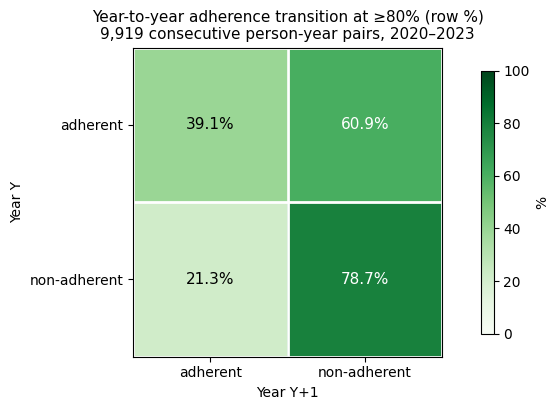

In [12]:
# Heatmap of the transition matrix, same layout as the 60% dashboard view.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.2))
im = ax.imshow(row_pct.values, cmap="Greens", vmin=0, vmax=100)

ax.set_xticks(range(len(STATES)), STATES)
ax.set_yticks(range(len(STATES)), STATES)
ax.set_xlabel("Year Y+1")
ax.set_ylabel("Year Y")
ax.set_title(
    f"Year-to-year adherence transition at ≥{ADH_THRESHOLD}% (row %)\n"
    f"{len(pairs):,} consecutive person-year pairs, 2020–2023",
    fontsize=11,
)

for i in range(len(STATES)):
    for j in range(len(STATES)):
        value = row_pct.values[i, j]
        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white" if value > 55 else "black",
            fontsize=11,
        )

ax.set_xticks(np.arange(-0.5, len(STATES), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(STATES), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)

fig.colorbar(im, ax=ax, label="%", shrink=0.85)
plt.tight_layout()
plt.show()

In [13]:
# Among pairs that started at ≥80%: where did they actually land, and by how much?
started_high = pairs[pairs["state_prev"] == "adherent"].copy()

LANDING_EDGES = [0, 40, 60, 70, ADH_THRESHOLD, 100.01]
LANDING_LABELS = [
    "<40%",
    f"40–<60%",
    f"60–<70%",
    f"70–<{ADH_THRESHOLD}%",
    f"Stayed ≥{ADH_THRESHOLD}%",
]
started_high["Landed"] = pd.cut(
    started_high["adh_next"], bins=LANDING_EDGES, labels=LANDING_LABELS, right=False
)

landing = (
    started_high.groupby("Landed", observed=False)
    .agg(
        **{
            "N pairs": ("DUPERSID", "size"),
            "Mean adherence Y": ("adh_prev", "mean"),
            "Mean adherence Y+1": ("adh_next", "mean"),
            "Mean change (pp)": ("adh_change", "mean"),
        }
    )
    .reset_index()
)
landing["% of those starting ≥80%"] = (
    100 * landing["N pairs"] / len(started_high)
).round(1)
landing = landing.round(1)

print(
    f"Of the {len(started_high):,} pairs that started at ≥{ADH_THRESHOLD}%, "
    f"here is where year Y+1 landed"
)
display(landing)

print(
    f"\nChange in adherence points among those starting ≥{ADH_THRESHOLD}%:\n"
    f"  mean {started_high['adh_change'].mean():+.1f} pp | "
    f"median {started_high['adh_change'].median():+.1f} pp\n"
    f"  fell by more than 20 pp: "
    f"{100 * (started_high['adh_change'] < -20).mean():.1f}% | "
    f"held within ±10 pp: "
    f"{100 * started_high['adh_change'].abs().le(10).mean():.1f}%"
)

# Does how far above the line you started change the odds of staying?
started_high["Starting band"] = pd.cut(
    started_high["adh_prev"],
    bins=[ADH_THRESHOLD, 90, 100.01],
    labels=[f"{ADH_THRESHOLD}–<90%", "90–100%"],
    right=False,
)
by_band = (
    started_high.groupby("Starting band", observed=False)
    .agg(
        **{
            "N pairs": ("DUPERSID", "size"),
            "Mean adherence Y": ("adh_prev", "mean"),
            "Mean adherence Y+1": ("adh_next", "mean"),
            "Mean change (pp)": ("adh_change", "mean"),
            f"% still ≥{ADH_THRESHOLD}% next year": (
                "state_next",
                lambda s: 100 * (s == "adherent").mean(),
            ),
        }
    )
    .reset_index()
    .round(1)
)
print("\nStaying power by how far above the line they started")
display(by_band)

Of the 3,084 pairs that started at ≥80%, here is where year Y+1 landed


,Landed,N pairs,Mean adherence Y,Mean adherence Y+1,Mean change (pp),% of those starting ≥80%
0,<40%,441,94.2,25.3,-68.9,14.3
1,40–<60%,592,93.6,50.6,-43.0,19.2
2,60–<70%,353,92.5,64.8,-27.8,11.4
3,70–<80%,491,93.2,74.7,-18.5,15.9
4,Stayed ≥80%,1207,94.2,94.0,-0.1,39.1



Change in adherence points among those starting ≥80%:
  mean -24.3 pp | median -20.9 pp
  fell by more than 20 pp: 51.1% | held within ±10 pp: 32.1%

Staying power by how far above the line they started


,Starting band,N pairs,Mean adherence Y,Mean adherence Y+1,Mean change (pp),% still ≥80% next year
0,80–<90%,914,84.2,68.6,-15.6,35.3
1,90–100%,2170,97.7,69.8,-27.9,40.7


## 9. Staying adherent throughout, and 5-point trajectories

Two person-level questions, both re-linking the same DUPERSID across years (same departure
from person-year independence as section 8).

**Coverage caveat.** No one in this extract is observed in all four years — MEPS panel
rotation caps it at three. 9,826 people appear once, 7,676 twice, and 1,171 three times
(2020–2022). "Throughout" therefore means *every year that person appears*, and the only
people for whom the phrase means anything are the 8,847 with two or more years.

**Trajectory margin.** A year-over-year move only counts as a rise or fall if it exceeds
**5 percentage points**; anything inside ±5 pp is treated as flat noise. A person whose
qualifying moves are all flat is `stable`. Classes are built on each person's longest run of
consecutive calendar years.

In [14]:
# TRAJECTORY SECTION — part 1: who stayed adherent in every year they appear.
person_years = (
    model_df[["DUPERSID", "YEAR", "meps_adherence_ratio"]]
    .dropna(subset=["meps_adherence_ratio"])
    .sort_values(["DUPERSID", "YEAR"])
    .copy()
)
person_years["is_adherent_80"] = person_years["meps_adherence_ratio"] >= ADH_THRESHOLD

person_status = (
    person_years.groupby("DUPERSID")
    .agg(
        n_years=("YEAR", "nunique"),
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        n_adherent_years=("is_adherent_80", "sum"),
        mean_adherence=("meps_adherence_ratio", "mean"),
        min_adherence=("meps_adherence_ratio", "min"),
        max_adherence=("meps_adherence_ratio", "max"),
    )
    .reset_index()
)
person_status["Status"] = np.select(
    [
        person_status["n_adherent_years"] == person_status["n_years"],
        person_status["n_adherent_years"] == 0,
    ],
    [f"Always ≥{ADH_THRESHOLD}%", f"Never ≥{ADH_THRESHOLD}%"],
    default="Mixed",
)

status_by_years = (
    pd.crosstab(person_status["n_years"], person_status["Status"])
    .reindex(
        columns=[f"Always ≥{ADH_THRESHOLD}%", "Mixed", f"Never ≥{ADH_THRESHOLD}%"],
        fill_value=0,
    )
    .rename_axis(index="Years observed")
    .reset_index()
)
status_by_years["Total people"] = status_by_years[
    [f"Always ≥{ADH_THRESHOLD}%", "Mixed", f"Never ≥{ADH_THRESHOLD}%"]
].sum(axis=1)
status_by_years[f"% always ≥{ADH_THRESHOLD}%"] = (
    100 * status_by_years[f"Always ≥{ADH_THRESHOLD}%"] / status_by_years["Total people"]
).round(1)

print(
    f"People: {len(person_status):,} | observed years per person: "
    f"{person_status['n_years'].value_counts().sort_index().to_dict()}\n"
    f"Nobody is observed in all four years — the longest coverage is three "
    f"(2020–2022, {int((person_status['n_years'] == 3).sum()):,} people)."
)
print("\nAdherence status across every year a person appears")
display(status_by_years)

multi = person_status[person_status["n_years"] >= 2]
always_multi = int((multi["Status"] == f"Always ≥{ADH_THRESHOLD}%").sum())
always_three = int(
    (
        (person_status["n_years"] == 3)
        & (person_status["Status"] == f"Always ≥{ADH_THRESHOLD}%")
    ).sum()
)
print(
    f"\nStayed adherent throughout, among the {len(multi):,} people seen in 2+ years: "
    f"{always_multi:,} ({100 * always_multi / len(multi):.1f}%)\n"
    f"  of whom, with the full three years of coverage: {always_three:,} "
    f"of {int((person_status['n_years'] == 3).sum()):,} "
    f"({100 * always_three / (person_status['n_years'] == 3).sum():.1f}%)\n"
    f"For contrast, never adherent in any year: "
    f"{int((multi['Status'] == f'Never ≥{ADH_THRESHOLD}%').sum()):,} "
    f"({100 * (multi['Status'] == f'Never ≥{ADH_THRESHOLD}%').mean():.1f}%)"
)

People: 18,673 | observed years per person: {1: 9826, 2: 7676, 3: 1171}
Nobody is observed in all four years — the longest coverage is three (2020–2022, 1,171 people).

Adherence status across every year a person appears


Status,Years observed,Always ≥80%,Mixed,Never ≥80%,Total people,% always ≥80%
0,1,2368,0,7458,9826,24.1
1,2,912,2604,4160,7676,11.9
2,3,79,582,510,1171,6.7



Stayed adherent throughout, among the 8,847 people seen in 2+ years: 991 (11.2%)
  of whom, with the full three years of coverage: 79 of 1,171 (6.7%)
For contrast, never adherent in any year: 4,670 (52.8%)


In [15]:
# TRAJECTORY SECTION — part 2: classify each person with a ±5 pp dead band.
TRAJECTORY_MARGIN = 5.0  # pp; moves smaller than this are treated as flat

TRAJECTORY_CLASSES = [
    "increasing",
    "decreasing",
    "recovering",
    "relapsing",
    "stable",
    "insufficient_years",
]


def classify_trajectory(deltas, margin=TRAJECTORY_MARGIN):
    """Label a sequence of year-over-year changes, ignoring moves inside ±margin.

    stable     — no move clears the margin
    increasing — every qualifying move is up
    decreasing — every qualifying move is down
    recovering — fell, then came back up and stayed up
    relapsing  — rose then fell, or fell-rose-fell
    """
    signs = "".join(
        "+" if d > margin else "-" if d < -margin else "" for d in deltas
    )
    if not signs:
        return "stable", signs
    if "-" not in signs:
        return "increasing", signs
    if "+" not in signs:
        return "decreasing", signs
    first_down = signs.find("-")
    later_up = signs.find("+", first_down + 1)
    if later_up != -1 and signs.find("-", later_up + 1) == -1:
        return "recovering", signs
    return "relapsing", signs


def longest_consecutive_run(years, values):
    """Longest stretch of consecutive calendar years, as (years, values)."""
    starts, cuts = 0, []
    for i in range(1, len(years)):
        if years[i] != years[i - 1] + 1:
            cuts.append((starts, i))
            starts = i
    cuts.append((starts, len(years)))
    a, b = max(cuts, key=lambda ab: ab[1] - ab[0])
    return years[a:b], values[a:b]


rows = []
for dupersid, g in person_years.groupby("DUPERSID", sort=False):
    years = g["YEAR"].to_numpy()
    values = g["meps_adherence_ratio"].to_numpy()
    run_years, run_values = longest_consecutive_run(years, values)

    if len(run_years) < 2:
        label, signs, deltas = "insufficient_years", "", []
    else:
        deltas = [
            run_values[i + 1] - run_values[i] for i in range(len(run_values) - 1)
        ]
        label, signs = classify_trajectory(deltas)

    rows.append(
        {
            "DUPERSID": dupersid,
            "trajectory_class": label,
            "n_years_observed": len(years),
            "n_years_in_run": len(run_years),
            "run_first_year": int(run_years[0]),
            "run_last_year": int(run_years[-1]),
            "adh_first": float(run_values[0]),
            "adh_last": float(run_values[-1]),
            "adh_min": float(run_values.min()),
            "adh_max": float(run_values.max()),
            "total_change_pp": float(run_values[-1] - run_values[0]),
            "max_abs_move_pp": float(max((abs(d) for d in deltas), default=0.0)),
            "sign_pattern": signs,
            "adherence_path": " → ".join(
                f"{int(y)}:{v:.0f}" for y, v in zip(run_years, run_values)
            ),
        }
    )

person_traj = pd.DataFrame(rows)

class_counts = (
    person_traj["trajectory_class"]
    .value_counts()
    .reindex(TRAJECTORY_CLASSES)
    .dropna()
    .astype(int)
    .rename("N people")
    .to_frame()
    .rename_axis("Trajectory")
    .reset_index()
)
class_counts["% of all people"] = (
    100 * class_counts["N people"] / class_counts["N people"].sum()
).round(1)
classifiable = person_traj[person_traj["trajectory_class"] != "insufficient_years"]
class_counts["% of classifiable"] = (
    100 * class_counts["N people"] / len(classifiable)
).round(1)
class_counts.loc[
    class_counts["Trajectory"] == "insufficient_years", "% of classifiable"
] = np.nan

print(
    f"Margin: moves within ±{TRAJECTORY_MARGIN:.0f} pp count as flat\n"
    f"People classified: {len(classifiable):,} with 2+ consecutive years | "
    f"{int((person_traj['trajectory_class'] == 'insufficient_years').sum()):,} "
    f"have only a single year and cannot be classified"
)
display(class_counts)

class_detail = (
    classifiable.groupby("trajectory_class", observed=True)
    .agg(
        **{
            "N people": ("DUPERSID", "size"),
            "Mean years in run": ("n_years_in_run", "mean"),
            "Mean first adherence": ("adh_first", "mean"),
            "Mean last adherence": ("adh_last", "mean"),
            "Mean total change (pp)": ("total_change_pp", "mean"),
            "Mean largest move (pp)": ("max_abs_move_pp", "mean"),
        }
    )
    .reindex([c for c in TRAJECTORY_CLASSES if c != "insufficient_years"])
    .dropna(how="all")
    .round(1)
    .reset_index()
    .rename(columns={"trajectory_class": "Trajectory"})
)
print("\nWhat each class looks like")
display(class_detail)

print("\nExamples (up to 4 per class)")
for cls in [c for c in TRAJECTORY_CLASSES if c != "insufficient_years"]:
    sample = classifiable[classifiable["trajectory_class"] == cls]
    if sample.empty:
        continue
    print(f"\n{cls} — sign pattern and path")
    display(
        sample.sort_values("n_years_in_run", ascending=False)
        .head(4)[["DUPERSID", "n_years_in_run", "sign_pattern", "adherence_path"]]
        .reset_index(drop=True)
    )

traj_path = TABLES_DIR / f"adherence_trajectories_{ADH_THRESHOLD}pct_margin{int(TRAJECTORY_MARGIN)}.csv"
person_traj.to_csv(traj_path, index=False)
print(f"\nWrote {len(person_traj):,} people → {traj_path}")

Margin: moves within ±5 pp count as flat
People classified: 8,748 with 2+ consecutive years | 9,925 have only a single year and cannot be classified


,Trajectory,N people,% of all people,% of classifiable
0,increasing,3062,16.4,35.0
1,decreasing,3730,20.0,42.6
2,recovering,305,1.6,3.5
3,relapsing,274,1.5,3.1
4,stable,1377,7.4,15.7
5,insufficient_years,9925,53.2,NaN



What each class looks like


,Trajectory,N people,Mean years in run,Mean first adherence,Mean last adherence,Mean total change (pp),Mean largest move (pp)
0,increasing,3062,2.1,46.9,75.8,28.9,28.5
1,decreasing,3730,2.1,76.8,46.6,-30.2,29.7
2,recovering,305,3.0,76.0,72.2,-3.9,40.5
3,relapsing,274,3.0,51.1,50.4,-0.7,38.2
4,stable,1377,2.0,68.8,68.7,-0.1,1.7



Examples (up to 4 per class)

increasing — sign pattern and path


...


relapsing — sign pattern and path


,DUPERSID,n_years_in_run,sign_pattern,adherence_path
0,2460040101,3,+-,2020:30 → 2021:49 → 2022:25
1,2466351102,3,+-,2020:47 → 2021:53 → 2022:43
2,2466610101,3,+-,2020:69 → 2021:82 → 2022:61
3,2466519101,3,+-,2020:35 → 2021:42 → 2022:14



stable — sign pattern and path


,DUPERSID,n_years_in_run,sign_pattern,adherence_path
0,2464675101,3,,2020:48 → 2021:46 → 2022:48
1,2461347103,3,,2020:78 → 2021:76 → 2022:77
2,2461231101,3,,2020:99 → 2021:99 → 2022:98
3,2461213102,3,,2020:99 → 2021:99 → 2022:99



Wrote 18,673 people → output/all_years/tables/adherence_trajectories_80pct_margin5.csv


Trajectory class vs adherence status across observed years


Status,Trajectory,Always ≥80%,Mixed,Never ≥80%,Total,% always ≥80%
0,increasing,217,1214,1631,3062,7.1
1,decreasing,230,1603,1897,3730,6.2
2,recovering,13,169,123,305,4.3
3,relapsing,7,140,127,274,2.6
4,stable,518,28,831,1377,37.6


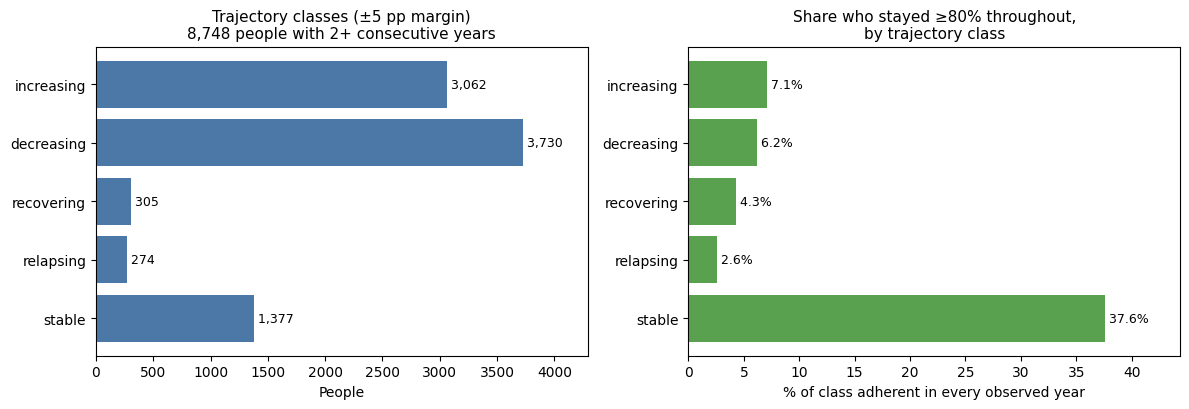

In [16]:
# TRAJECTORY SECTION — part 3: trajectory class against staying adherent throughout.
traj_status = person_traj.merge(
    person_status[["DUPERSID", "Status", "n_adherent_years", "n_years"]],
    on="DUPERSID",
    how="left",
)
traj_status = traj_status[traj_status["trajectory_class"] != "insufficient_years"]

cross = (
    pd.crosstab(traj_status["trajectory_class"], traj_status["Status"])
    .reindex(
        index=[c for c in TRAJECTORY_CLASSES if c != "insufficient_years"],
        columns=[f"Always ≥{ADH_THRESHOLD}%", "Mixed", f"Never ≥{ADH_THRESHOLD}%"],
        fill_value=0,
    )
    .rename_axis(index="Trajectory")
)
cross["Total"] = cross.sum(axis=1)
cross[f"% always ≥{ADH_THRESHOLD}%"] = (
    100 * cross[f"Always ≥{ADH_THRESHOLD}%"] / cross["Total"]
).round(1)

print(f"Trajectory class vs adherence status across observed years")
display(cross.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

plot_counts = class_counts[class_counts["Trajectory"] != "insufficient_years"]
axes[0].barh(plot_counts["Trajectory"], plot_counts["N people"], color="#4C78A8")
axes[0].invert_yaxis()
axes[0].set_xlabel("People")
axes[0].set_title(
    f"Trajectory classes (±{TRAJECTORY_MARGIN:.0f} pp margin)\n"
    f"{len(classifiable):,} people with 2+ consecutive years",
    fontsize=11,
)
for y, (label, value) in enumerate(
    zip(plot_counts["Trajectory"], plot_counts["N people"])
):
    axes[0].text(value, y, f" {value:,}", va="center", fontsize=9)
axes[0].margins(x=0.15)

share = cross[f"% always ≥{ADH_THRESHOLD}%"]
axes[1].barh(share.index, share.to_numpy(), color="#59A14F")
axes[1].invert_yaxis()
axes[1].set_xlabel(f"% of class adherent in every observed year")
axes[1].set_title(
    f"Share who stayed ≥{ADH_THRESHOLD}% throughout,\nby trajectory class",
    fontsize=11,
)
for y, value in enumerate(share.to_numpy()):
    axes[1].text(value, y, f" {value:.1f}%", va="center", fontsize=9)
axes[1].margins(x=0.18)

plt.tight_layout()
plt.show()